# ShiftSync Analytics Notebook

This notebook analyzes generated shift handover metrics for ShiftSync AI.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path('../powerbi/sample_handover_metrics.csv')
df = pd.read_csv(csv_path)
df


,handover_id,shift_date,shift_start,shift_end,events_scanned,events_in_window,unique_records,duplicates_removed,completed,in_progress,blockers,watchlist,low_risk,medium_risk,high_risk,critical_risk
0,1,2026-09-03,17:00,20:00,7,5,4,1,1,1,1,1,1,1,1,1


## Core Shift Metrics


In [2]:
metrics = df[['events_scanned', 'events_in_window', 'unique_records', 'duplicates_removed']]
metrics


,events_scanned,events_in_window,unique_records,duplicates_removed
0,7,5,4,1


## Duplicate Rate


In [3]:
df['duplicate_rate_percent'] = (
    df['duplicates_removed'] / df['events_in_window'].replace(0, pd.NA) * 100
).round(2)

df[['handover_id', 'duplicate_rate_percent']]


,handover_id,duplicate_rate_percent
0,1,20.0


## Handover Section Distribution


In [4]:
section_totals = df[['completed', 'in_progress', 'blockers', 'watchlist']].sum()
section_totals


completed      1
in_progress    1
blockers       1
watchlist      1
dtype: int64

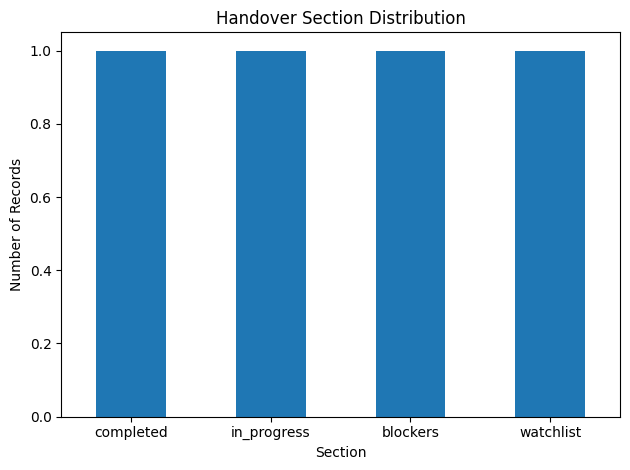

In [5]:
section_totals.plot(kind='bar')
plt.title('Handover Section Distribution')
plt.xlabel('Section')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Risk Distribution


In [6]:
risk_totals = df[['low_risk', 'medium_risk', 'high_risk', 'critical_risk']].sum()
risk_totals


low_risk         1
medium_risk      1
high_risk        1
critical_risk    1
dtype: int64

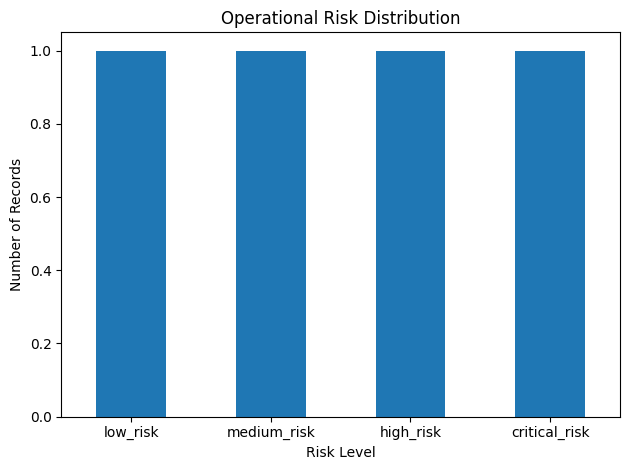

In [7]:
risk_totals.plot(kind='bar')
plt.title('Operational Risk Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Shift Efficiency


In [8]:
df['window_utilization_percent'] = (
    df['events_in_window'] / df['events_scanned'].replace(0, pd.NA) * 100
).round(2)

df['unique_record_percent'] = (
    df['unique_records'] / df['events_in_window'].replace(0, pd.NA) * 100
).round(2)

df[['handover_id', 'window_utilization_percent', 'unique_record_percent', 'duplicate_rate_percent']]


,handover_id,window_utilization_percent,unique_record_percent,duplicate_rate_percent
0,1,71.43,80.0,20.0


## Verified Demo Summary

For the demo shift 03 September 2026, 17:00–20:00 IST:

- 7 events scanned
- 5 events inside the selected shift
- 4 unique operational records
- 1 duplicate removed
- 1 Completed item
- 1 In Progress item
- 1 Blocker
- 1 Watch-list item
